In [1]:
using Plots
using Plots.PlotMeasures
using HDF5

### Initial Parameters ###

In [2]:
N = 5 #Number of lattice sites per dimension
d = 1 #Number of spatial dimensions
Dim = 10 #Truncated local Hilbert space dimension
a = 1 #Lattice spacing

n_0 = round(Int, ((N-1)/2)) #Index of the point at the center of the lattice (0-based indexing).
dp = 2pi/(N*a) #Discrete change in momentum

mass = 1
m0 = 1 #Basis frequency
l = 0.1; #phi^4 coupling strength

### Check Energy Conservation ###

In [3]:
#Load Data
data = h5open("Z:/1d_EEC_data/EVs,N=5,a=1.0,l=0.1,m=1.0,ti=0,tf=5", "r")
Edens0 = data["Edens0"][1:end]
EfluxR = data["EfluxR"][1:end]
EfluxL = data["EfluxL"][1:end]
close(data)

In [4]:
t_max = 5
dt = 0.1
t_range = range(0, t_max, step=dt)
t_inds = range(1, length(t_range))

function CalcEdensOut(t_ind)
    s_range = range(1, t_ind-1)
    Edens = 0
    for s_ind in s_range
        #Edens += dt*(EfluxL[s_ind] + EfluxR[s_ind])
        Edens += 1/2*dt*((EfluxL[s_ind]+EfluxL[s_ind+1]) + (EfluxR[s_ind]+EfluxR[s_ind+1]))
    end
    return Edens
end

EdensTot = [Edens0[t_ind] + CalcEdensOut(t_ind) for t_ind in t_inds]
residuals = EdensTot .- Edens0[1]

51-element Vector{ComplexF64}:
                    0.0 + 0.0im
  1.5584005379487564e-6 + 1.0505240880606822e-10im
    4.99628503947136e-6 + 1.907949120347701e-9im
  1.1897329259547007e-5 + 3.1486812205105487e-9im
  2.0798287171608365e-5 + 4.165935484794477e-9im
   3.511118837407068e-5 + 5.08848283636174e-9im
  4.8633374660767004e-5 + 5.934931391820686e-9im
   5.320479529080657e-5 + 6.9839445701022685e-9im
   5.141315529089141e-5 + 7.632269891966167e-9im
   4.086392324209598e-5 + 8.194379324061598e-9im
  1.5941322525581114e-5 + 8.417802845023311e-9im
 -2.0116329249475484e-5 + 8.814183800073542e-9im
  -6.118084778972133e-5 + 9.908269146821308e-9im
                        ⋮
   -9.89300063087839e-5 - 4.019970617947003e-9im
  -7.339811397377716e-5 - 3.171711627245719e-9im
  -4.861326305594105e-5 + 3.309883136897775e-9im
 -2.4105030784760118e-5 + 1.4006065504388932e-8im
 -1.4480119983062423e-6 + 1.4513879358901837e-8im
   2.053986687933218e-5 + 5.925892666897035e-9im
     4.2491315423554e-5 

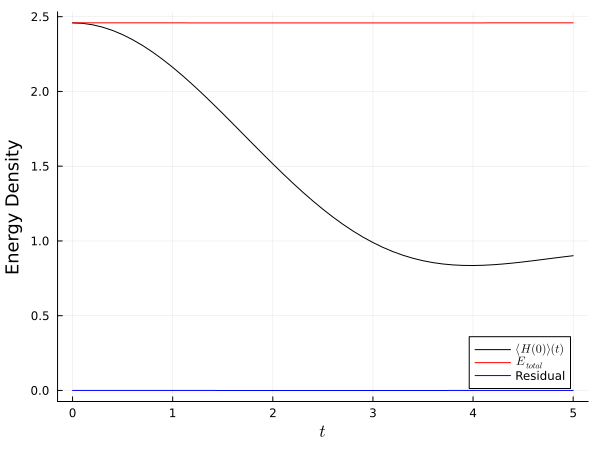

In [5]:
plot(t_range, real(Edens0),
    guidefont=font(12),
    xlabel="\$t\$",
    ylabel="Energy Density",
    size=(600, 450),
    color="black",
    label="\$⟨{H(0)}⟩(t)\$")
plot!(t_range, real(EdensTot), color="red", label="\$E_{total}\$")
plot!(t_range, real(residuals), color="blue", label="Residual")
#savefig("Plots/Energy Conservation, N=5, m=1, lambda=1e-1, truncated HS dim=10")

In [6]:
#Expected outgoing energy density
real(Edens0[1].-Edens0)
#Calculated outgoing energy density
real(EdensTot - Edens0)
#Multiplicative Error
real(EdensTot - Edens0) ./ real(Edens0[1].-Edens0)

51-element Vector{Float64}:
 NaN
   1.0004845556320103
   1.0003891756944026
   1.00041344434132
   1.0004087636524925
   1.0004447826679221
   1.0004315658857903
   1.0003504556970426
   1.000262387340068
   1.000167021786193
   1.0000535792809702
   0.9999431841288324
   0.999852135441295
   ⋮
   0.9999390221858744
   0.9999547785495732
   0.9999700198516185
   0.9999851020667684
   0.9999991022276665
   1.0000127856272094
   1.0000265722812525
   1.0000402957323709
   1.0000534316896876
   1.0000663055937393
   1.0000781928730222
   1.0000877703819522